In [4]:
from helmholtz import *
from tools import avg_pool2d

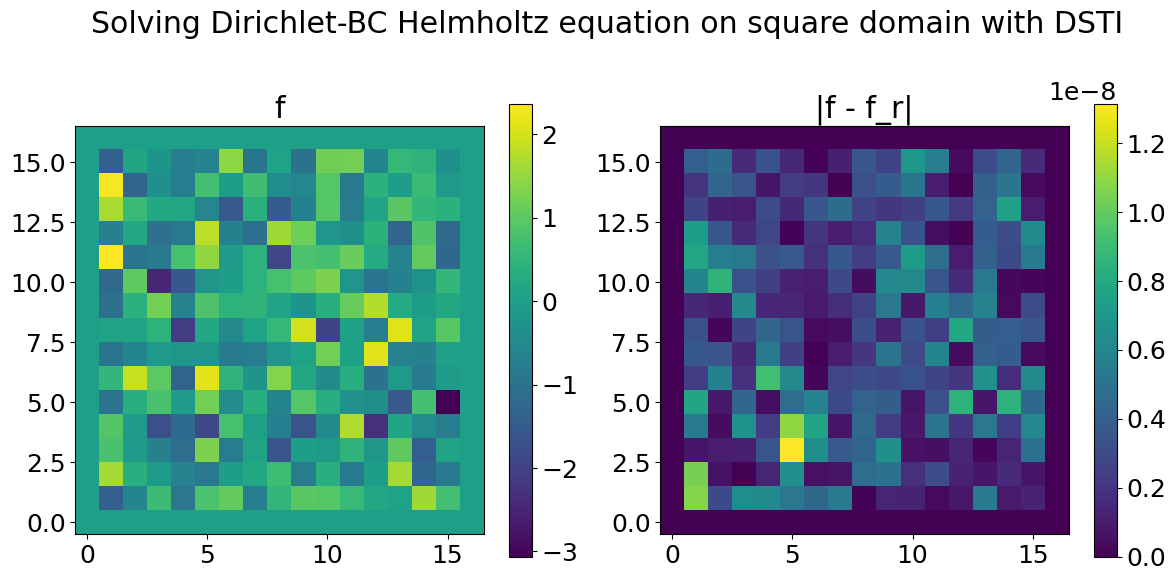

In [5]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from jax import numpy as jnp 

matplotlib.rcParams.update({'font.size': 18})
plt.ion()

dtype = jnp.float64

# grid
N = 4
nx, ny = 2*2**(N-1), 2*2**(N-1)
shape = (nx, ny)
L = 2000e3
xc = jnp.linspace(-L, L, nx+1, dtype=dtype)
yc = jnp.linspace(-L, L, ny+1, dtype=dtype)
xx, yy = jnp.meshgrid(xc, yc, indexing='ij')
dx = xc[1] - xc[0]
dy = yc[1] - yc[0]

# Helmholtz eq.
lambd = 1e-2 * jnp.ones([1,1,1],dtype=dtype)
helmholtz_dirichletbc = lambda f, dx, dy, lambd: \
        (f[...,2:,1:-1] + f[...,:-2,1:-1] - 2*f[...,1:-1,1:-1])/dx**2 \
    + (f[...,1:-1,2:] + f[...,1:-1,:-2] - 2*f[...,1:-1,1:-1])/dy**2 \
    - lambd * f[...,1:-1,1:-1]
helmholtz_dstI = compute_laplace_dstI(
        nx, ny, dx, dy, {'dtype':dtype}) \
        - lambd


# Rectangular domain
frect = jnp.zeros([1, nx+1, ny+1], dtype=dtype)
frect = frect.at[...,1:-1,1:-1].set(
    jax.random.normal(jax.random.PRNGKey(0), shape=frect[...,1:-1,1:-1].shape))
Hfrect = helmholtz_dirichletbc(frect, dx, dy, lambd)
frect_r = solve_helmholtz_dstI(Hfrect, helmholtz_dstI)
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].set_title('f')
fig.colorbar(ax[0].imshow(frect[0], origin='lower'), ax=ax[0])
ax[1].set_title('|f - f_r|')
fig.colorbar(ax[1].imshow(jnp.abs(frect - frect_r)[0], origin='lower'), ax=ax[1])
fig.suptitle('Solving Dirichlet-BC Helmholtz equation on square domain with DSTI')
fig.savefig('helmholtz_rect.png')
fig.tight_layout()

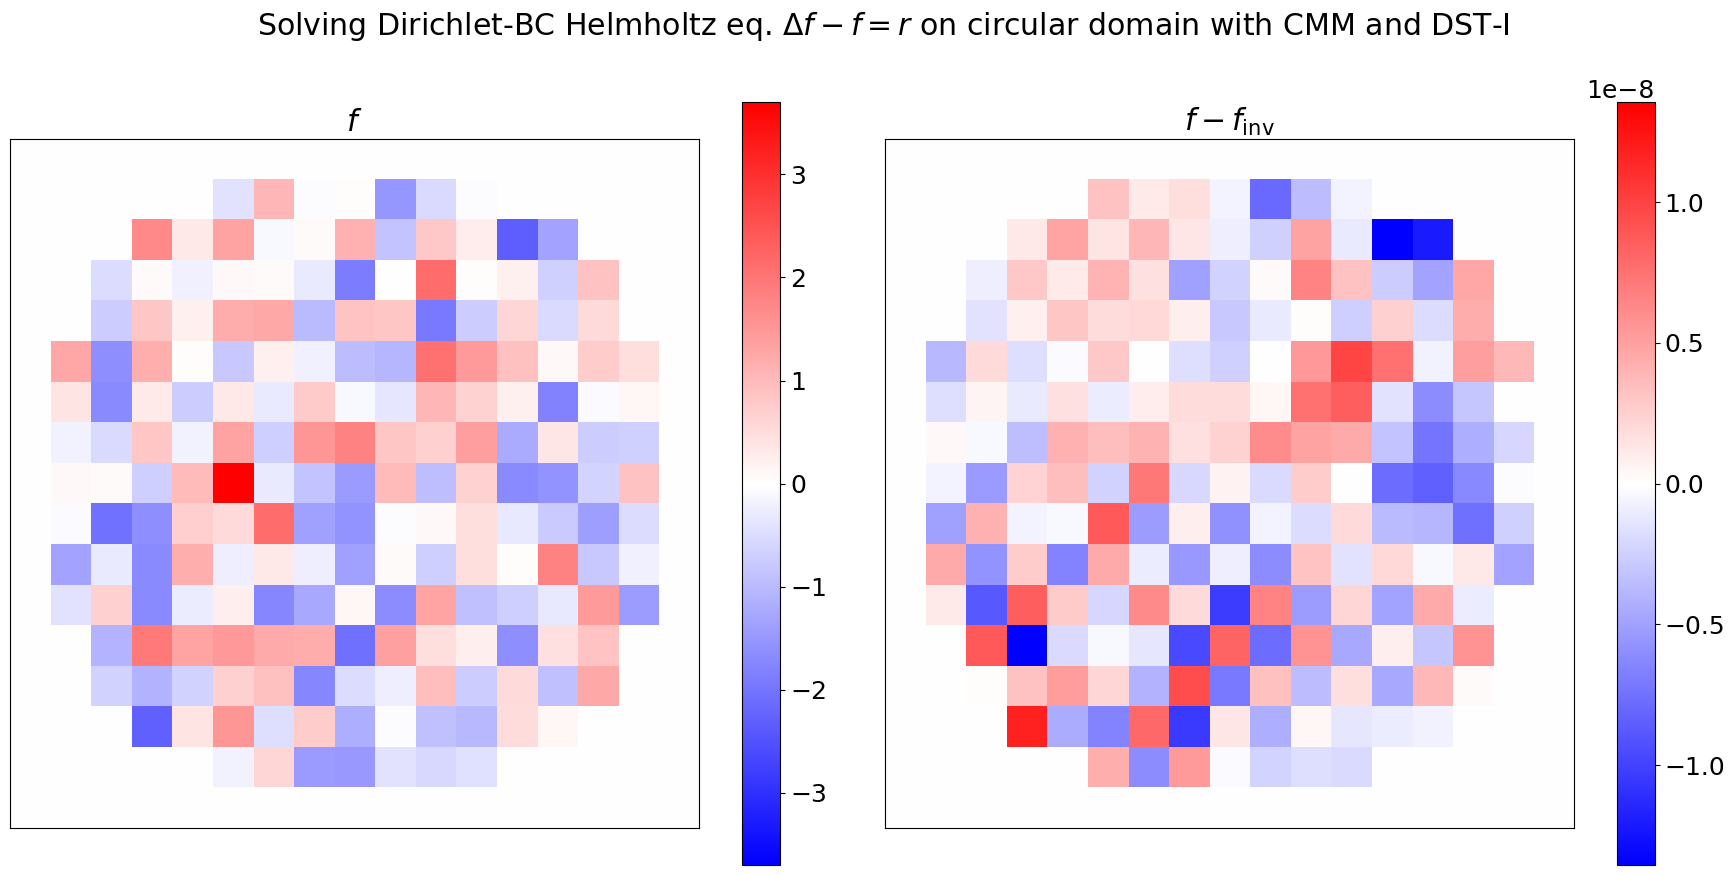

In [6]:
# Circular domain
mask = (1 > ((xx/L)**2 + (yy/L)**2)).astype(dtype)
mask = mask.at[[0,-1],:].set(0)
mask = mask.at[0,-1].set(0)
domain_neighbor = \
    avg_pool2d(mask.reshape((1,1)+mask.shape), kernel_size=3, stride=1, padding=0)[0,0] > 0
irrbound_xids, irrbound_yids = jnp.where(
        jnp.logical_and(mask[1:-1,1:-1] < 0.5, domain_neighbor))
cap_matrices = compute_capacitance_matrices(
        helmholtz_dstI, irrbound_xids,
        irrbound_yids)

key = jax.random.PRNGKey(0)
fcirc = mask * jnp.expand_dims(jax.random.normal(key, shape=mask.shape), 0)
#fcirc = mask * jnp.zeros_like(mask).normal_().unsqueeze(0)
Hfcirc = helmholtz_dirichletbc(fcirc, dx, dy, lambd) * mask[1:-1,1:-1]
fcirc_r = solve_helmholtz_dstI_cmm(Hfcirc, helmholtz_dstI,
                        cap_matrices, irrbound_xids,
                        irrbound_yids, mask)

palette = plt.cm.bwr.with_extremes(bad='grey')
fig, ax = plt.subplots(1,2, figsize=(18,9))
ax[0].set_title('$f$')
vM = np.abs(fcirc[0]).max()
# fcirc_ma = np.ma.masked_where((1-mask).cpu().numpy(), fcirc[0].cpu().numpy())
fcirc_ma = fcirc[0]
fig.colorbar(ax[0].imshow(fcirc_ma.T, vmin=-vM, vmax=vM, origin='lower', cmap=palette), ax=ax[0])
ax[1].set_title('$f - f_{\\rm inv}$')
diff =( fcirc - fcirc_r)[0]
vM = np.abs(diff).max()
# diff_ma = np.ma.masked_where((1-mask).cpu().numpy(), diff)
diff_ma =diff
fig.colorbar(ax[1].imshow(diff_ma.T, vmin=-vM, vmax=vM, origin='lower', cmap=palette), ax=ax[1])
fig.suptitle('Solving Dirichlet-BC Helmholtz eq. $\\Delta f - f = r$ on circular domain with CMM and DST-I')
ax[0].set_xticks([]), ax[1].set_xticks([]), ax[0].set_yticks([]), ax[1].set_yticks([])
fig.savefig('helmholtz_circular.png')
fig.tight_layout()

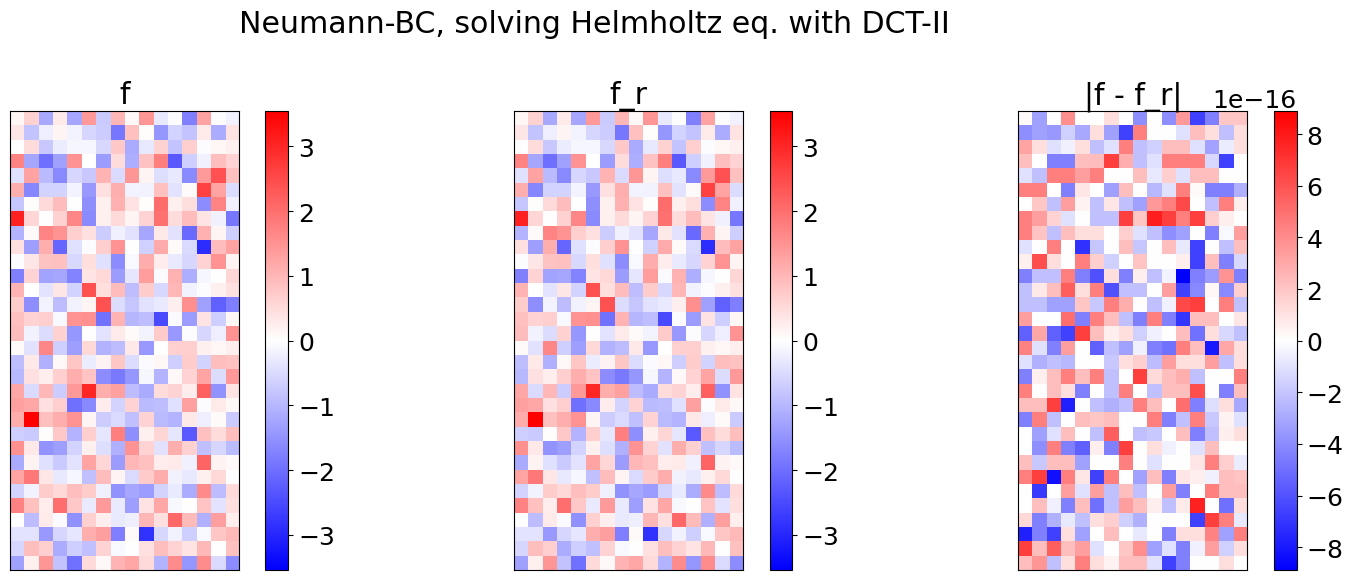

In [7]:
## Neumann BC
dx, dy = 20000, 20000
lambd = jnp.ones((1,1,1)).astype(dtype) / dx * dy

N = 32
nx, ny = N//2, N
key = jax.random.PRNGKey(0)
f1 = jax.random.normal(key, shape=[1, nx, ny])
mask1 = jnp.ones((nx, ny), dtype=dtype)

solver1 = HelmholtzNeumannSolver(
        nx, ny, dx, dy, lambd, dtype, mask=mask1)

H_f1 = solver1.helmholtz(f1)
f1_r = solver1.solve(H_f1)

vM = max(np.abs(f1).max().item(), np.max(f1_r).item())
diff = (f1 - f1_r) * mask1
vM2 = np.abs(diff).max().item()

fig, ax = plt.subplots(1,3, figsize=(16,6))
ax[0].set_title('f')
fig.colorbar(ax[0].imshow(f1[0].T, vmin=-vM, vmax=vM, cmap='bwr', origin='lower'), ax=ax[0])
ax[1].set_title('f_r')
fig.colorbar(ax[1].imshow(f1_r[0].T, vmin=-vM, vmax=vM, cmap='bwr', origin='lower'), ax=ax[1])
ax[2].set_title('|f - f_r|')
fig.colorbar(ax[2].imshow(diff[0].T, vmin=-vM2, vmax=vM2, cmap='bwr', origin='lower'), ax=ax[2])
fig.suptitle('Neumann-BC, solving Helmholtz eq. with DCT-II')
ax[0].set_xticks([]), ax[1].set_xticks([]), ax[2].set_xticks([])
ax[0].set_yticks([]), ax[1].set_yticks([]), ax[2].set_yticks([])
fig.savefig('Neumann-BC_1.png')
fig.tight_layout()

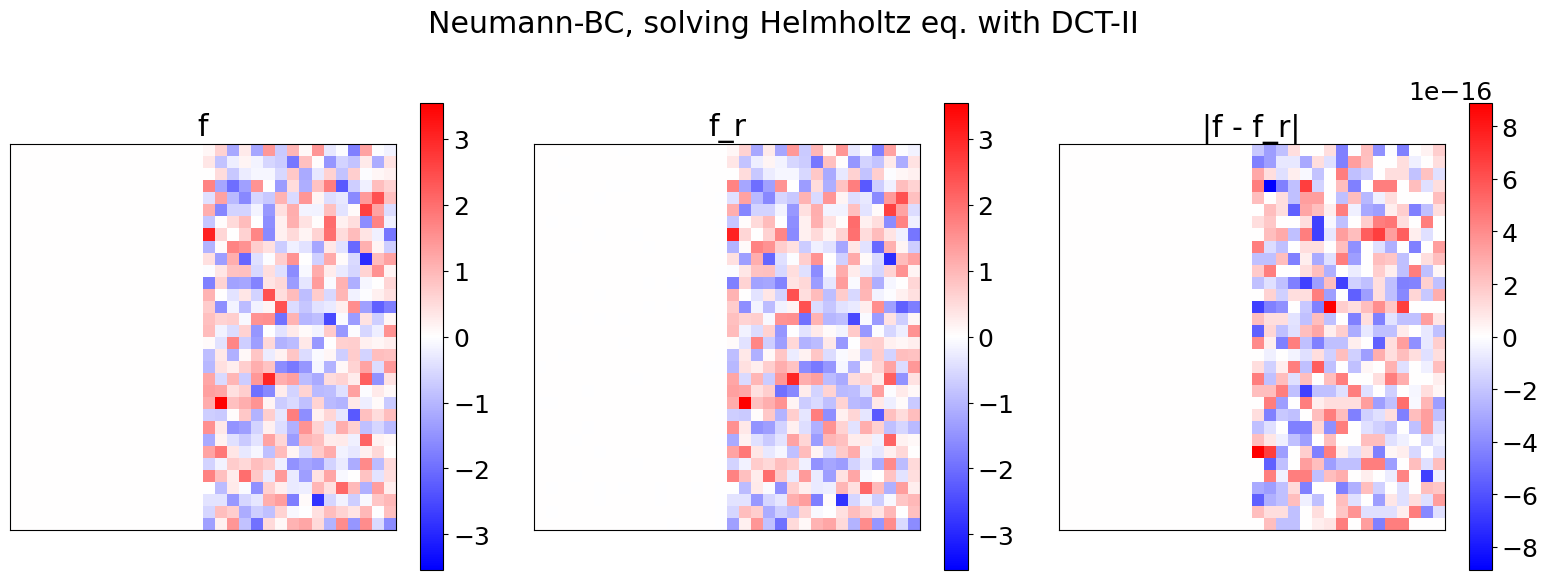

: 

In [ ]:
#
nx, ny = N, N
f2 = jnp.zeros((1, nx, ny), dtype=dtype)
f2 = f2.at[:,N//2:,:].set(f1)
mask2 = jnp.ones((nx, ny), dtype=dtype)
mask2 = mask2.at[:N//2,:].set(0)

solver2 = HelmholtzNeumannSolver(
        nx, ny, dx, dy, lambd, dtype, mask=mask2)

H_f2 = solver2.helmholtz(f2)
f2_r = solver2.solve(H_f2)

vM = max(np.abs(f2).max().item(), np.max(f2_r).item())
diff = (f2 - f2_r) * mask2
vM2 = np.abs(diff).max().item()

fig, ax = plt.subplots(1,3, figsize=(16,6))
ax[0].set_title('f')
fig.colorbar(ax[0].imshow(f2[0].T, vmin=-vM, vmax=vM, cmap='bwr', origin='lower'), ax=ax[0])
ax[1].set_title('f_r')
fig.colorbar(ax[1].imshow(f2_r[0].T, vmin=-vM, vmax=vM, cmap='bwr', origin='lower'), ax=ax[1])
ax[2].set_title('|f - f_r|')
fig.colorbar(ax[2].imshow(diff[0].T, vmin=-vM2, vmax=vM2, cmap='bwr', origin='lower'), ax=ax[2])
fig.suptitle('Neumann-BC, solving Helmholtz eq. with DCT-II')
ax[0].set_xticks([]), ax[1].set_xticks([]), ax[2].set_xticks([])
ax[0].set_yticks([]), ax[1].set_yticks([]), ax[2].set_yticks([])
fig.savefig('Neumann-BC_2.png')
fig.tight_layout()